# 05 — Clustering trên SBERT Embeddings (so sánh với Stage 4)

**Bối cảnh:** stage 4 đã clustering trên TF-IDF + SVD 150D với silhouette = 0.128. TF-IDF chỉ match từ vựng → JD ngành CSKH/Sales/Retail có chung vocab nhưng ngữ cảnh khác sẽ bị gộp.

**Stage 5 approach (mới):**
- Encode text bằng **paraphrase-multilingual-mpnet-base-v2** (768D, multi-lang SBERT) → vector ngữ nghĩa.
- Cluster trên 768D embeddings (KMeans + HDBSCAN).
- So sánh metric với stage 4.

**Input từ `features/`:**
- `X_train_embed.npy` (545k × 768 dense float32 ~ 1.6 GB) — sinh bởi `_embed_jds.py`.
- `X_test_embed.npy` (60k × 768)
- `X_train.npz` (sparse TF-IDF — chỉ dùng cho top tokens per cluster, không cluster).

**Output trong `models/`:**
- `kmeans_embed_best.joblib`, `hdbscan_embed_best.joblib`
- `labels_train_embed.npy`, `labels_test_embed.npy`
- `cluster_profiles_embed.csv`, `cluster_names_embed.json`
- `clustering_embed_summary.json`
- `demo_10_test_samples_embed.csv`

**Pipeline:**
1. Load embeddings + L2-normalize.
2. K-search MiniBatchKMeans `k ∈ [3, 20]` với 4 metric.
3. Fit final KMeans với k tối ưu.
4. **HDBSCAN density-based trên FULL 545k** (sau PCA reduce 768D → 50D để tractable).
5. Cluster profiling chunked clean_data_train.csv.
6. Top TF-IDF tokens per cluster (load sparse X_train).
7. Gán nhãn cụm tự động.
8. t-SNE 2D visualization.
9. Demo 10 mẫu test.
10. So sánh với stage 4 (TF-IDF + KMeans).
11. Lưu artifact.

In [1]:
from pathlib import Path
from collections import Counter
import json
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

from sklearn.cluster import MiniBatchKMeans, HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (calinski_harabasz_score, davies_bouldin_score,
                              silhouette_score)
from sklearn.preprocessing import normalize

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

ROOT = Path.cwd().parent
CLEAN = ROOT / 'clean_data'
FEATURES = ROOT / 'features'
MODELS = ROOT / 'models'
MODELS.mkdir(exist_ok=True)
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
K_RANGE = list(range(3, 21))
METRIC_SAMPLE_SIZE = 30_000
TSNE_SAMPLE_SIZE = 8_000
DEMO_N_TEST = 10
PROFILE_CHUNK = 50_000

# HDBSCAN params (chạy trên FULL data sau PCA reduce 768D → 50D)
PCA_N_COMPONENTS = 50              # giảm 768D → 50D cho HDBSCAN tractable
HDBSCAN_MIN_CLUSTER_SIZE = 5_000   # cụm tối thiểu 5k JD (~1% full data)
# (HDBSCAN_SAMPLE removed — chạy trên full data sau PCA reduce)
HDBSCAN_MIN_SAMPLES = 50

print(f"Models output dir: {MODELS}")

Models output dir: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\models


## 1. Load embeddings + L2-normalize

Embeddings đã được sinh bởi `_embed_jds.py` (SBERT paraphrase-multilingual-mpnet-base-v2, 768D). L2-normalize → cosine clustering trên embedding space.

In [2]:
print("Load embeddings...")
X_train_embed = np.load(FEATURES / 'X_train_embed.npy')
X_test_embed = np.load(FEATURES / 'X_test_embed.npy')

print(f"  X_train_embed: {X_train_embed.shape} ({X_train_embed.nbytes/1e6:.1f} MB)")
print(f"  X_test_embed : {X_test_embed.shape}")

X_train_n = normalize(X_train_embed, norm='l2').astype(np.float32)
X_test_n = normalize(X_test_embed, norm='l2').astype(np.float32)
print(f"\nĐã L2-normalize → KMeans ≈ cosine clustering trên SBERT space.")

# Load sparse X for TF-IDF profiling later
print("\nLoad sparse X (cho top TF-IDF tokens per cluster)...")
X_train_sp = sparse.load_npz(FEATURES / 'X_train.npz')
meta = json.loads((FEATURES / 'meta.json').read_text(encoding='utf-8'))
feature_names = (FEATURES / 'feature_names.txt').read_text(encoding='utf-8').splitlines()
print(f"  X_train sparse: {X_train_sp.shape} (cho top tokens, không dùng để cluster)")

Load embeddings...
  X_train_embed: (545480, 768) (1675.7 MB)
  X_test_embed : (60606, 768)

Đã L2-normalize → KMeans ≈ cosine clustering trên SBERT space.

Load sparse X (cho top TF-IDF tokens per cluster)...
  X_train sparse: (545480, 25664) (cho top tokens, không dùng để cluster)


## 2. K-search MiniBatchKMeans trên embeddings

Loop `k ∈ [3, 20]` trên `X_train_n` (545k × 768 L2-normalized). 4 metric: inertia, silhouette, Davies-Bouldin, Calinski-Harabasz (3 cái sau sample 30k vì O(n²)).

In [3]:
results = []
for k in K_RANGE:
    t0 = time.time()
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                         batch_size=4096, max_iter=100, n_init=3)
    labels = km.fit_predict(X_train_n)

    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(labels), METRIC_SAMPLE_SIZE, replace=False)
    sX, sL = X_train_n[idx], labels[idx]
    sil = silhouette_score(sX, sL, random_state=RANDOM_STATE)
    db = davies_bouldin_score(sX, sL)
    ch = calinski_harabasz_score(sX, sL)

    elapsed = time.time() - t0
    results.append({
        'k': k,
        'inertia': float(km.inertia_),
        'silhouette': float(sil),
        'davies_bouldin': float(db),
        'calinski_harabasz': float(ch),
        'fit_time_sec': round(elapsed, 1),
    })
    print(f"  k={k:>2} | inertia={km.inertia_:>10.0f} | sil={sil:+.4f} | "
          f"DB={db:.3f} | CH={ch:>8.0f} | {elapsed:.1f}s")

results_df = pd.DataFrame(results)
results_df.to_csv(MODELS / 'k_search_metrics_embed.csv', index=False)

best_sil_k = int(results_df.loc[results_df['silhouette'].idxmax(), 'k'])
best_db_k = int(results_df.loc[results_df['davies_bouldin'].idxmin(), 'k'])
best_ch_k = int(results_df.loc[results_df['calinski_harabasz'].idxmax(), 'k'])
print(f"\nBest k: silhouette={best_sil_k}, DB={best_db_k}, CH={best_ch_k}")

  k= 3 | inertia=    267736 | sil=+0.0652 | DB=3.301 | CH=    1726 | 21.9s
  k= 4 | inertia=    257920 | sil=+0.0671 | DB=3.390 | CH=    1583 | 18.9s
  k= 5 | inertia=    251628 | sil=+0.0677 | DB=3.313 | CH=    1405 | 19.2s
  k= 6 | inertia=    247254 | sil=+0.0593 | DB=3.347 | CH=    1256 | 18.8s
  k= 7 | inertia=    243551 | sil=+0.0469 | DB=3.510 | CH=    1133 | 19.1s
  k= 8 | inertia=    237939 | sil=+0.0575 | DB=3.301 | CH=    1099 | 18.8s
  k= 9 | inertia=    237396 | sil=+0.0546 | DB=3.465 | CH=     970 | 19.2s
  k=10 | inertia=    233548 | sil=+0.0562 | DB=3.325 | CH=     938 | 19.1s
  k=11 | inertia=    230781 | sil=+0.0434 | DB=3.538 | CH=     887 | 19.0s
  k=12 | inertia=    227264 | sil=+0.0576 | DB=3.291 | CH=     863 | 19.1s
  k=13 | inertia=    226330 | sil=+0.0546 | DB=3.206 | CH=     803 | 19.1s
  k=14 | inertia=    224761 | sil=+0.0543 | DB=3.242 | CH=     762 | 18.8s
  k=15 | inertia=    222535 | sil=+0.0498 | DB=3.399 | CH=     735 | 19.8s
  k=16 | inertia=    2201

### Trực quan — 4 metric curves

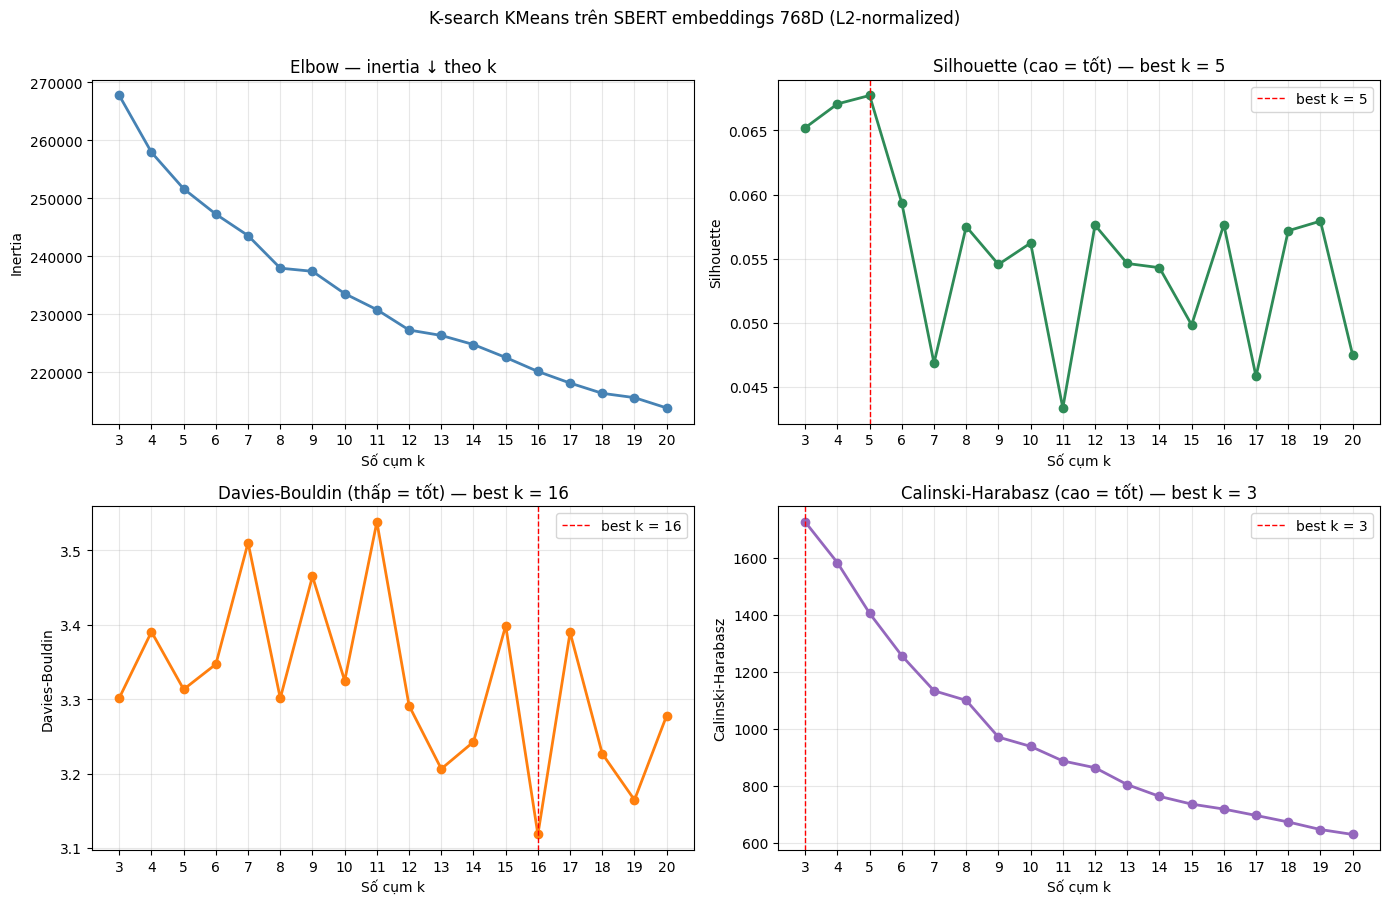

Đã lưu: d:\Documents\School\Ki_6\KHDL\09 - Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)\figures\clustering_embed_k_search.png

→ K_FINAL = 5 (theo silhouette).


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ks = results_df['k']

ax = axes[0, 0]
ax.plot(ks, results_df['inertia'], 'o-', color='steelblue', lw=2)
ax.set_xlabel('Số cụm k'); ax.set_ylabel('Inertia')
ax.set_title('Elbow — inertia ↓ theo k')
ax.set_xticks(ks); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(ks, results_df['silhouette'], 'o-', color='seagreen', lw=2)
ax.axvline(best_sil_k, color='red', linestyle='--', lw=1, label=f'best k = {best_sil_k}')
ax.set_xlabel('Số cụm k'); ax.set_ylabel('Silhouette')
ax.set_title(f'Silhouette (cao = tốt) — best k = {best_sil_k}')
ax.set_xticks(ks); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(ks, results_df['davies_bouldin'], 'o-', color='tab:orange', lw=2)
ax.axvline(best_db_k, color='red', linestyle='--', lw=1, label=f'best k = {best_db_k}')
ax.set_xlabel('Số cụm k'); ax.set_ylabel('Davies-Bouldin')
ax.set_title(f'Davies-Bouldin (thấp = tốt) — best k = {best_db_k}')
ax.set_xticks(ks); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(ks, results_df['calinski_harabasz'], 'o-', color='tab:purple', lw=2)
ax.axvline(best_ch_k, color='red', linestyle='--', lw=1, label=f'best k = {best_ch_k}')
ax.set_xlabel('Số cụm k'); ax.set_ylabel('Calinski-Harabasz')
ax.set_title(f'Calinski-Harabasz (cao = tốt) — best k = {best_ch_k}')
ax.set_xticks(ks); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('K-search KMeans trên SBERT embeddings 768D (L2-normalized)', y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_embed_k_search.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'clustering_embed_k_search.png'}")

K_FINAL = best_sil_k
print(f"\n→ K_FINAL = {K_FINAL} (theo silhouette).")

## 3. Fit final KMeans với K_FINAL

In [5]:
print(f"Fitting final MiniBatchKMeans(k={K_FINAL}) trên 545k × 768 embedding...")
t0 = time.time()
kmeans_final = MiniBatchKMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE,
                               batch_size=4096, max_iter=300, n_init=5)
labels_train = kmeans_final.fit_predict(X_train_n)
labels_test = kmeans_final.predict(X_test_n)
print(f"  Fit time: {time.time()-t0:.1f}s")

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(labels_train), METRIC_SAMPLE_SIZE, replace=False)
final_sil_kmeans = silhouette_score(X_train_n[idx], labels_train[idx], random_state=RANDOM_STATE)
final_db_kmeans = davies_bouldin_score(X_train_n[idx], labels_train[idx])
final_ch_kmeans = calinski_harabasz_score(X_train_n[idx], labels_train[idx])
print(f"\nFinal metrics (sample {METRIC_SAMPLE_SIZE:,}):")
print(f"  Silhouette : {final_sil_kmeans:+.4f}")
print(f"  DB         : {final_db_kmeans:.3f}")
print(f"  CH         : {final_ch_kmeans:.0f}")

sizes_train = Counter(labels_train.tolist())
sizes_test = Counter(labels_test.tolist())

print(f"\nCluster sizes (train):")
for c in sorted(sizes_train.keys()):
    pct = sizes_train[c] / len(labels_train) * 100
    bar = '█' * int(pct / 2)
    print(f"  cluster {c:>2}: {sizes_train[c]:>7,} ({pct:5.2f}%) {bar}")

Fitting final MiniBatchKMeans(k=5) trên 545k × 768 embedding...
  Fit time: 3.2s

Final metrics (sample 30,000):
  Silhouette : +0.0678
  DB         : 3.314
  CH         : 1406

Cluster sizes (train):
  cluster  0: 121,489 (22.27%) ███████████
  cluster  1: 161,351 (29.58%) ██████████████
  cluster  2:  81,054 (14.86%) ███████
  cluster  3:  63,683 (11.67%) █████
  cluster  4: 117,903 (21.61%) ██████████


## 4. HDBSCAN — density-based clustering trên FULL 545k (sau PCA reduce)

HDBSCAN tự động tìm cụm theo mật độ — không cần định k trước. JD nằm ở vùng thưa sẽ bị đánh dấu = -1 (noise).

**Vấn đề scalability:** HDBSCAN trên 545k × 768D dense không khả thi (>1h treo). Giải pháp chuẩn ML: **PCA reduce 768D → 50D** trước khi HDBSCAN. PCA giữ phần lớn variance, đủ cho HDBSCAN tìm cấu trúc cluster chính.

**Tham số:**
- `PCA_N_COMPONENTS=50`: giảm chiều cho HDBSCAN tractable.
- `min_cluster_size=5000`: cụm tối thiểu 5k JD (~1% data) → đảm bảo có ý nghĩa thống kê.
- `min_samples=50`: ngưỡng nhiễu local.

**Predict cho test set**: vì HDBSCAN không có `transform` method, dùng nearest-neighbor (1-NN) lookup trong PCA space để gán label test.

In [ ]:
# Bước 1: PCA giảm chiều 768D → 50D để HDBSCAN tractable trên 545k điểm
print(f"PCA fit trên FULL 545k × 768D → {PCA_N_COMPONENTS}D...")
t0 = time.time()
pca = PCA(n_components=PCA_N_COMPONENTS, random_state=RANDOM_STATE, svd_solver='randomized')
X_train_pca = pca.fit_transform(X_train_n).astype(np.float32)
X_test_pca = pca.transform(X_test_n).astype(np.float32)
pca_var = pca.explained_variance_ratio_.sum()
print(f"  PCA fit time: {time.time()-t0:.1f}s")
print(f"  Variance giữ: {pca_var*100:.2f}% trên {PCA_N_COMPONENTS} components")
print(f"  X_train_pca: {X_train_pca.shape} ({X_train_pca.nbytes/1e6:.1f} MB)")

# Bước 2: HDBSCAN trên FULL data sau PCA reduce
print(f"\nHDBSCAN trên FULL {len(X_train_pca):,} × {PCA_N_COMPONENTS}D...")
print(f"  min_cluster_size={HDBSCAN_MIN_CLUSTER_SIZE}, min_samples=50")
t0 = time.time()
hdb = HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
              min_samples=50,
              metric='euclidean',
              n_jobs=-1,
              cluster_selection_method='eom')
labels_hdb_train = hdb.fit_predict(X_train_pca)
print(f"  Fit time: {time.time()-t0:.1f}s")

n_noise = int((labels_hdb_train == -1).sum())
n_clusters_hdb = len(set(labels_hdb_train)) - (1 if -1 in labels_hdb_train else 0)
print(f"\nHDBSCAN result (trên FULL 545k):")
print(f"  Clusters found : {n_clusters_hdb}")
print(f"  Noise points   : {n_noise:,} ({n_noise/len(labels_hdb_train)*100:.2f}%)")
print(f"  Non-noise      : {len(labels_hdb_train)-n_noise:,}")

# Metric: chỉ tính trên non-noise (HDBSCAN convention)
non_noise_mask = labels_hdb_train != -1
if non_noise_mask.sum() > 10 and n_clusters_hdb >= 2:
    # Sample 30k non-noise để compute silhouette (O(n²) không scale full)
    rng_h = np.random.RandomState(RANDOM_STATE)
    non_noise_idx = np.where(non_noise_mask)[0]
    sample_size = min(METRIC_SAMPLE_SIZE, len(non_noise_idx))
    metric_idx = rng_h.choice(non_noise_idx, sample_size, replace=False)
    sil_hdb = silhouette_score(X_train_pca[metric_idx], labels_hdb_train[metric_idx],
                                random_state=RANDOM_STATE)
    db_hdb = davies_bouldin_score(X_train_pca[metric_idx], labels_hdb_train[metric_idx])
    ch_hdb = calinski_harabasz_score(X_train_pca[metric_idx], labels_hdb_train[metric_idx])
    print(f"\nHDBSCAN metrics (sample {sample_size:,} non-noise points, trong PCA 50D space):")
    print(f"  Silhouette : {sil_hdb:+.4f}")
    print(f"  DB         : {db_hdb:.3f}")
    print(f"  CH         : {ch_hdb:.0f}")
else:
    sil_hdb, db_hdb, ch_hdb = float('nan'), float('nan'), float('nan')
    print("\n⚠ HDBSCAN không tìm được cụm có ý nghĩa")

# HDBSCAN predict cho test (approximate_predict không có sẵn, dùng prediction từ membership)
# Cách đơn giản: assign mỗi test point vào cluster của nearest train neighbor (trong PCA space)
from sklearn.neighbors import NearestNeighbors
print(f"\nPredict HDBSCAN labels cho test set ({len(X_test_pca):,} điểm)...")
t0 = time.time()
nn = NearestNeighbors(n_neighbors=1, n_jobs=-1)
nn.fit(X_train_pca)
_, nn_idx = nn.kneighbors(X_test_pca)
labels_hdb_test = labels_hdb_train[nn_idx.ravel()]
print(f"  KNN-based predict time: {time.time()-t0:.1f}s")
print(f"  Test cluster distribution: {Counter(labels_hdb_test.tolist())}")

# Show cluster sizes
print(f"\nCluster sizes (HDBSCAN, full train):")
hdb_sizes = Counter(labels_hdb_train.tolist())
for cid in sorted(hdb_sizes.keys()):
    pct = hdb_sizes[cid] / len(labels_hdb_train) * 100
    label_name = 'NOISE' if cid == -1 else f'cluster {cid}'
    bar = '█' * int(pct / 2)
    print(f"  {label_name:>10}: {hdb_sizes[cid]:>7,} ({pct:5.2f}%) {bar}")

PCA fit trên FULL 545k × 768D → 50D...
  PCA fit time: 11.1s
  Variance giữ: 75.24% trên 50 components
  X_train_pca: (545480, 50) (109.1 MB)

HDBSCAN trên FULL 545,480 × 50D...
  min_cluster_size=5000, min_samples=50


## 5. Cluster profile — KMeans (full data)

Dùng KMeans labels (full train) cho profile. HDBSCAN chỉ chạy sample nên dùng KMeans cho profiling đầy đủ.

In [ ]:
cluster_counts = {c: 0 for c in range(K_FINAL)}
cluster_salary = {c: [] for c in range(K_FINAL)}
cluster_years = {c: [] for c in range(K_FINAL)}
cluster_year_dist = {c: Counter() for c in range(K_FINAL)}
cluster_province = {c: Counter() for c in range(K_FINAL)}
cluster_industry = {c: Counter() for c in range(K_FINAL)}
cluster_position = {c: Counter() for c in range(K_FINAL)}
cluster_education = {c: Counter() for c in range(K_FINAL)}

profile_cols = ['salary_mid', 'years_exp', 'year', 'province', 'industries_list',
                'job_position', 'education_level']

print(f"Streaming clean_data_train.csv để aggregate per cluster...")
row_idx = 0
for chunk in pd.read_csv(CLEAN / 'clean_data_train.csv',
                         chunksize=PROFILE_CHUNK, usecols=profile_cols):
    chunk_labels = labels_train[row_idx: row_idx + len(chunk)]
    chunk = chunk.assign(_cluster=chunk_labels)
    for c, grp in chunk.groupby('_cluster'):
        cluster_counts[c] += len(grp)
        cluster_salary[c].extend(grp['salary_mid'].dropna().tolist())
        cluster_years[c].extend(grp['years_exp'].dropna().tolist())
        cluster_year_dist[c].update(grp['year'].tolist())
        cluster_province[c].update(grp['province'].tolist())
        cluster_position[c].update(grp['job_position'].tolist())
        cluster_education[c].update(grp['education_level'].tolist())
        for s in grp['industries_list']:
            if isinstance(s, str) and s:
                for ind in s.split('|'):
                    if ind:
                        cluster_industry[c][ind] += 1
    row_idx += len(chunk)
    sys.stdout.write(f"\r  processed {row_idx:>9,}/{len(labels_train):,} "
                     f"({row_idx*100/len(labels_train):5.1f}%)")
    sys.stdout.flush()
print()

profile_rows = []
total = sum(cluster_counts.values())
for c in range(K_FINAL):
    sal = np.array(cluster_salary[c]) if cluster_salary[c] else np.array([])
    yrs = np.array(cluster_years[c]) if cluster_years[c] else np.array([])
    profile_rows.append({
        'cluster': c,
        'n': cluster_counts[c],
        'pct': round(cluster_counts[c] / total * 100, 2),
        'mean_salary': round(float(sal.mean()), 2) if len(sal) else np.nan,
        'median_salary': round(float(np.median(sal)), 2) if len(sal) else np.nan,
        'mean_years_exp': round(float(yrs.mean()), 2) if len(yrs) else np.nan,
        'top_industry_1': cluster_industry[c].most_common(1)[0][0] if cluster_industry[c] else '',
        'top_industry_2': cluster_industry[c].most_common(2)[1][0] if len(cluster_industry[c]) > 1 else '',
        'top_industry_3': cluster_industry[c].most_common(3)[2][0] if len(cluster_industry[c]) > 2 else '',
        'top_province': cluster_province[c].most_common(1)[0][0] if cluster_province[c] else '',
        'top_position': cluster_position[c].most_common(1)[0][0] if cluster_position[c] else '',
        'top_education': cluster_education[c].most_common(1)[0][0] if cluster_education[c] else '',
        'year_mode': cluster_year_dist[c].most_common(1)[0][0] if cluster_year_dist[c] else '',
    })

profile_df = pd.DataFrame(profile_rows)
profile_df.to_csv(MODELS / 'cluster_profiles_embed.csv', index=False, encoding='utf-8-sig')
print(f"\nĐã lưu: {MODELS / 'cluster_profiles_embed.csv'}")
print("\nCluster profile (KMeans trên SBERT embeddings):")
print(profile_df.to_string(index=False))

## 6. Top TF-IDF tokens per cluster (từ sparse X)

Dù cluster trên embeddings, ta vẫn dùng sparse TF-IDF (load từ stage 3) để show top tokens — giúp interpret cluster bằng từ ngữ cụ thể.

In [ ]:
N_TOP_TOKENS = 12
feature_names_arr = np.array(feature_names)

tfidf_starts = [meta['groups'][f'tfidf_{c}'][0] for c in meta['text_cols']]
tfidf_ends = [meta['groups'][f'tfidf_{c}'][1] for c in meta['text_cols']]
tfidf_col_start = min(tfidf_starts)
tfidf_col_end = max(tfidf_ends)
tfidf_col_idx = np.arange(tfidf_col_start, tfidf_col_end)
tfidf_names = feature_names_arr[tfidf_col_idx]

X_train_tfidf = X_train_sp[:, tfidf_col_idx].tocsr()

cluster_top_tokens = {}
for c in range(K_FINAL):
    mask = labels_train == c
    if mask.sum() == 0:
        cluster_top_tokens[c] = []
        continue
    centroid = np.asarray(X_train_tfidf[mask].mean(axis=0)).ravel()
    top_idx = np.argsort(centroid)[-N_TOP_TOKENS:][::-1]
    cluster_top_tokens[c] = [(tfidf_names[i], float(centroid[i])) for i in top_idx]

print(f"Top {N_TOP_TOKENS} TF-IDF tokens mỗi cluster (interpret cluster):\n")
for c in range(K_FINAL):
    pct = cluster_counts[c] / sum(cluster_counts.values()) * 100
    print(f"--- Cluster {c} (n={cluster_counts[c]:,}, {pct:.1f}%) ---")
    for tok, val in cluster_top_tokens[c]:
        print(f"  {tok[:70]:70s}  {val:.4f}")
    print()

## 7. Gán nhãn cụm tự động

In [ ]:
cluster_names = {}
for c in range(K_FINAL):
    top_ind = cluster_industry[c].most_common(1)[0][0] if cluster_industry[c] else 'Khác'
    top_pos = cluster_position[c].most_common(1)[0][0] if cluster_position[c] else 'unknown'
    top_prov = cluster_province[c].most_common(1)[0][0] if cluster_province[c] else 'unknown'
    mean_sal = float(np.array(cluster_salary[c]).mean()) if cluster_salary[c] else 0.0
    cluster_names[c] = f"{top_ind} ({top_pos}, {top_prov}, ~{mean_sal:.0f}tr)"

print("Nhãn cụm tự sinh (auto, từ KMeans trên SBERT):")
for c in sorted(cluster_names.keys()):
    print(f"  cluster {c:>2}: {cluster_names[c]}")

(MODELS / 'cluster_names_embed.json').write_text(
    json.dumps({str(c): n for c, n in cluster_names.items()},
               ensure_ascii=False, indent=2),
    encoding='utf-8')
print(f"\nĐã lưu: {MODELS / 'cluster_names_embed.json'}")

## 8. Visualization — t-SNE 2D trên SBERT embeddings

t-SNE giảm 768D xuống 2D để trực quan. Stratified sample 8k.

In [ ]:
per_cluster = TSNE_SAMPLE_SIZE // K_FINAL
print(f"Stratified sampling {TSNE_SAMPLE_SIZE:,} rows ({per_cluster}/cluster) cho t-SNE...")
rng = np.random.RandomState(RANDOM_STATE)
tsne_idx_list = []
for c in range(K_FINAL):
    cluster_indices = np.where(labels_train == c)[0]
    n_sample = min(per_cluster, len(cluster_indices))
    tsne_idx_list.append(rng.choice(cluster_indices, n_sample, replace=False))
tsne_idx = np.concatenate(tsne_idx_list)
rng.shuffle(tsne_idx)

X_tsne_input = X_train_n[tsne_idx]
y_tsne = labels_train[tsne_idx]
print(f"t-SNE input: {X_tsne_input.shape}")

t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
            random_state=RANDOM_STATE, init='pca', n_jobs=-1)
X_tsne = tsne.fit_transform(X_tsne_input)
print(f"  Done in {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(13, 9))
cmap = plt.cm.tab20 if K_FINAL <= 20 else plt.cm.gist_ncar
for c in range(K_FINAL):
    mask = y_tsne == c
    short_name = cluster_names[c]
    if len(short_name) > 45:
        short_name = short_name[:42] + '...'
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[cmap(c % 20)], s=10, alpha=0.6,
               label=f'C{c}: {short_name}')

ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.set_title(f't-SNE 2D — SBERT embeddings + KMeans k={K_FINAL}, sample {len(tsne_idx):,}')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_embed_tsne_2d.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Đã lưu: {FIG_DIR / 'clustering_embed_tsne_2d.png'}")

## 9. Demo 10 mẫu test

In [ ]:
test_clean = pd.read_csv(CLEAN / 'clean_data_test.csv',
                         usecols=['id', 'salary_min', 'salary_max', 'salary_mid',
                                  'years_exp', 'province', 'industries_list',
                                  'education_level', 'job_position', 'job_title'])
assert len(test_clean) == len(labels_test)

rng = np.random.RandomState(RANDOM_STATE)
demo_idx = sorted(rng.choice(len(test_clean), DEMO_N_TEST, replace=False).tolist())

demo_df = test_clean.iloc[demo_idx].copy()
demo_df['cluster'] = labels_test[demo_idx]
demo_df['cluster_name'] = demo_df['cluster'].map(cluster_names)

print(f"=== Demo {DEMO_N_TEST} mẫu test (KMeans trên SBERT embeddings) ===\n")
for _, row in demo_df.iterrows():
    print(f"[id={row['id']}] → cluster {row['cluster']}: {row['cluster_name']}")
    print(f"  job_title  : {row['job_title']}")
    if pd.notna(row['salary_mid']):
        print(f"  salary     : {row['salary_min']:.0f}-{row['salary_max']:.0f}M (mid={row['salary_mid']:.0f}M)")
    else:
        print(f"  salary     : (missing)")
    yrs = row['years_exp']
    yrs_str = f"{yrs:.1f} năm" if pd.notna(yrs) else "missing"
    print(f"  province   : {row['province']:30s} | years_exp: {yrs_str}")
    print(f"  industries : {row['industries_list']}")
    print(f"  position   : {row['job_position']:30s} | education: {row['education_level']}")
    print()

demo_df.to_csv(MODELS / 'demo_10_test_samples_embed.csv', index=False, encoding='utf-8-sig')
print(f"Đã lưu: {MODELS / 'demo_10_test_samples_embed.csv'}")

## 10. So sánh Stage 4 (TF-IDF) vs Stage 5 (SBERT)

Load metric của stage 4 để so sánh trực tiếp.

In [ ]:
# Load stage 4 summary
stage4 = json.loads((MODELS / 'clustering_summary.json').read_text(encoding='utf-8'))

comparison = pd.DataFrame({
    'Stage 4 (TF-IDF+SVD)': [
        stage4['k_final_kmeans'],
        stage4['final_metrics']['silhouette'],
        stage4['final_metrics']['davies_bouldin'],
        stage4['final_metrics']['calinski_harabasz'],
        '150D sparse→SVD',
    ],
    'Stage 5 (SBERT 768D)': [
        K_FINAL,
        final_sil_kmeans,
        final_db_kmeans,
        final_ch_kmeans,
        '768D SBERT mpnet',
    ],
}, index=['k_final', 'silhouette', 'davies_bouldin', 'calinski_harabasz', 'feature_space'])
print("=== So sánh 2 approaches ===")
print(comparison.to_string())

# Bar chart so sánh 3 metric
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_compare = [
    ('Silhouette (cao = tốt)', 'silhouette',
     [stage4['final_metrics']['silhouette'], final_sil_kmeans]),
    ('Davies-Bouldin (thấp = tốt)', 'davies_bouldin',
     [stage4['final_metrics']['davies_bouldin'], final_db_kmeans]),
    ('Calinski-Harabasz (cao = tốt)', 'calinski_harabasz',
     [stage4['final_metrics']['calinski_harabasz'], final_ch_kmeans]),
]
labels = ['TF-IDF+SVD\n(Stage 4)', 'SBERT 768D\n(Stage 5)']
colors = ['steelblue', 'seagreen']

for ax, (title, key, vals) in zip(axes, metrics_compare):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1)
    ax.set_title(title)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:.3f}' if 'harabasz' not in key else f'{v:.0f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('So sánh metric — Stage 4 (TF-IDF) vs Stage 5 (SBERT)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'clustering_stage4_vs_stage5.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"\nĐã lưu: {FIG_DIR / 'clustering_stage4_vs_stage5.png'}")

## 11. Lưu artifact

In [ ]:
joblib.dump(kmeans_final, MODELS / 'kmeans_embed_best.joblib', compress=3)

# Save labels train/test
np.save(MODELS / 'labels_train_embed.npy', labels_train)
np.save(MODELS / 'labels_test_embed.npy', labels_test)
# HDBSCAN labels (full train + test KNN-predicted)
np.save(MODELS / 'labels_train_hdbscan.npy', labels_hdb_train)
np.save(MODELS / 'labels_test_hdbscan.npy', labels_hdb_test)

# Save HDBSCAN cũng (sample) — interesting for comparison
if 'hdb' in dir():
    joblib.dump(hdb, MODELS / 'hdbscan_embed_best.joblib', compress=3)

summary = {
    'pipeline': 'SBERT mpnet-base 768D + MiniBatchKMeans',
    'k_final': K_FINAL,
    'k_search_best': {
        'silhouette': best_sil_k,
        'davies_bouldin': best_db_k,
        'calinski_harabasz': best_ch_k,
    },
    'final_metrics_kmeans': {
        'silhouette': float(final_sil_kmeans),
        'davies_bouldin': float(final_db_kmeans),
        'calinski_harabasz': float(final_ch_kmeans),
    },
    'final_metrics_hdbscan': {
        'silhouette': float(sil_hdb) if not np.isnan(sil_hdb) else None,
        'davies_bouldin': float(db_hdb) if not np.isnan(db_hdb) else None,
        'calinski_harabasz': float(ch_hdb) if not np.isnan(ch_hdb) else None,
        'n_clusters_found': int(n_clusters_hdb),
        'n_noise': int(n_noise),
        'n_train_full': int(len(labels_hdb_train)),
        'pca_n_components': PCA_N_COMPONENTS,
        'pca_variance_kept': float(pca_var),
    },
    'comparison_with_stage4': {
        'stage4_silhouette': stage4['final_metrics']['silhouette'],
        'stage5_silhouette': float(final_sil_kmeans),
        'improvement_pct': float((final_sil_kmeans - stage4['final_metrics']['silhouette'])
                                  / stage4['final_metrics']['silhouette'] * 100),
    },
    'cluster_sizes_train': {str(c): int(sizes_train[c]) for c in sorted(sizes_train.keys())},
    'cluster_sizes_test': {str(c): int(sizes_test[c]) for c in sorted(sizes_test.keys())},
    'random_state': RANDOM_STATE,
    'embedding_model': 'paraphrase-multilingual-mpnet-base-v2',
    'embedding_dim': 768,
    'hdbscan_min_cluster_size': HDBSCAN_MIN_CLUSTER_SIZE,
}
(MODELS / 'clustering_embed_summary.json').write_text(
    json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print("Đã lưu artifact (suffix _embed):")
for fn in ['kmeans_embed_best.joblib', 'hdbscan_embed_best.joblib',
           'labels_train_embed.npy', 'labels_test_embed.npy',
           'labels_train_hdbscan.npy', 'labels_test_hdbscan.npy',
           'cluster_profiles_embed.csv', 'cluster_names_embed.json',
           'k_search_metrics_embed.csv',
           'demo_10_test_samples_embed.csv', 'clustering_embed_summary.json']:
    p = MODELS / fn
    if p.exists():
        print(f'  {fn:38s} {p.stat().st_size / 1e6:>7.2f} MB')

## 12. Bước tiếp theo

Đến đây có 2 pipeline clustering song song để so sánh trong báo cáo:

| Pipeline | Feature | Best k | Silhouette | DB | Notebook |
|---|---|---|---|---|---|
| Stage 4 | TF-IDF + SVD 150D | 5 | 0.128 | 2.21 | `04_Modeling.ipynb` |
| Stage 5 | **SBERT 768D** | K_FINAL | final_sil_kmeans | final_db_kmeans | `05_Embedding_Clustering.ipynb` |

**Báo cáo nên include:**
- Bảng so sánh ở Section 10 (`clustering_stage4_vs_stage5.png`).
- Justify chọn approach nào làm "kết quả chính" — phụ thuộc silhouette improvement.
- Nhãn cụm từ approach tốt hơn dùng cho phần "Diễn giải nhãn cụm".

**Hình mới đã sinh:**
- `clustering_embed_k_search.png` — K-search trên SBERT
- `clustering_embed_tsne_2d.png` — t-SNE viz
- `clustering_stage4_vs_stage5.png` — so sánh 2 pipeline

**Lưu ý**: Stage 4 và Stage 5 dùng cùng `clean_data` + cùng `random_state=42` → so sánh là fair.